<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week2/notebooks/Class2_2_LogisticRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

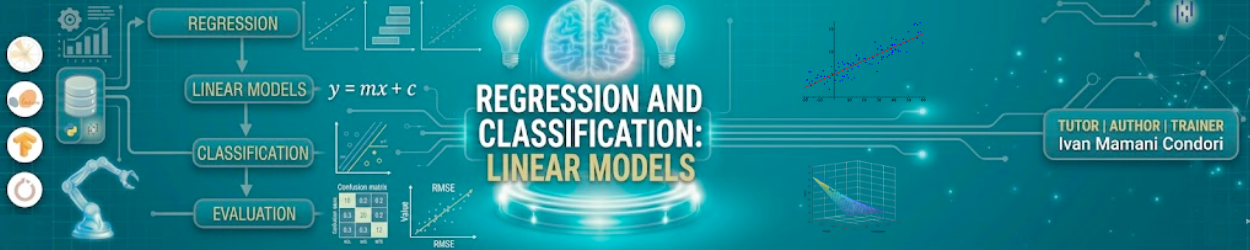

# Logistic Regression – Breast Cancer Coimbra Dataset

**Dataset:** Breast Cancer Coimbra

**Fonte:** UCI Machine Learning Repository

**Link:** https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra

**Objetivo:**
Analisar variáveis clínicas e metabólicas de pacientes para ***prever a presença de câncer de mama*** utilizando técnicas de classificação supervisionada.

O modelo buscará estimar a probabilidade de um paciente pertencer a uma das classes da variável Classification:
- 1 → Paciente saudável
- 2 → Paciente com câncer de mama

Este é um ***problema de classificação binária***, onde o objetivo é identificar padrões nas características biomédicas que permitam distinguir entre pacientes saudáveis e pacientes diagnosticados com câncer.

**Autor:** Ivan Mamani

---

## 1. Importação das Bibliotecas

In [ ]:
# Biblioteca para manipulação de dados em formato de tabelas (DataFrame)
import pandas as pd

# Biblioteca para cálculos matemáticos e operações numéricas
import numpy as np

# Biblioteca para criação de gráficos
import matplotlib.pyplot as plt

# Biblioteca para gráficos estatísticos mais avançados
import seaborn as sns

# Biblioteca para divisão de dados em treino e teste
from sklearn.model_selection import train_test_split

# Biblioteca para normalização dos dados
from sklearn.preprocessing import StandardScaler

# Modelo de regressão logística
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configuração estética dos gráficos
sns.set(style="whitegrid")

## 2. Carregamento do Dataset

In [ ]:
# URL oficial do dataset Coimbra no repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

# Lê o arquivo CSV diretamente da URL e armazena no DataFrame df
df = pd.read_csv(url)

# Mostra as primeiras 5 linhas do dataset
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [ ]:
# Verifica o tamanho do dataset
df.shape

(116, 10)

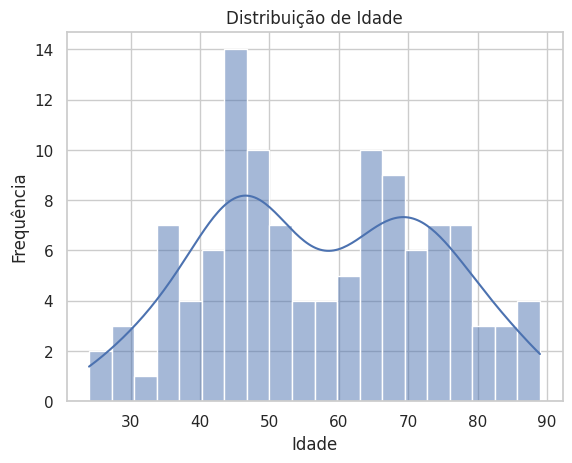

In [ ]:
# Histograma da variável Age
plt.figure()
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")

plt.show()

**Insights**

O dataset contém variáveis biomédicas como:
- Age
- BMI
- Glucose
- Insulin
- HOMA
- Leptin
- Adiponectin
- Resistin
- MCP.1

A variável Classification indica:
- 1 → saudável
- 2 → câncer de mama

**❓ Perguntas**

- O que é um dataset?

- Quantas observações existem no dataset?

- O que representa a variável Classification?

## 3. Limpeza de Dados

In [ ]:
# Verifica informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [ ]:
# Verifica valores ausentes
df.isnull().sum()

,0
Age,0
BMI,0
Glucose,0
Insulin,0
HOMA,0
Leptin,0
Adiponectin,0
Resistin,0
MCP.1,0
Classification,0


In [ ]:
# Estatísticas descritivas do dataset
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


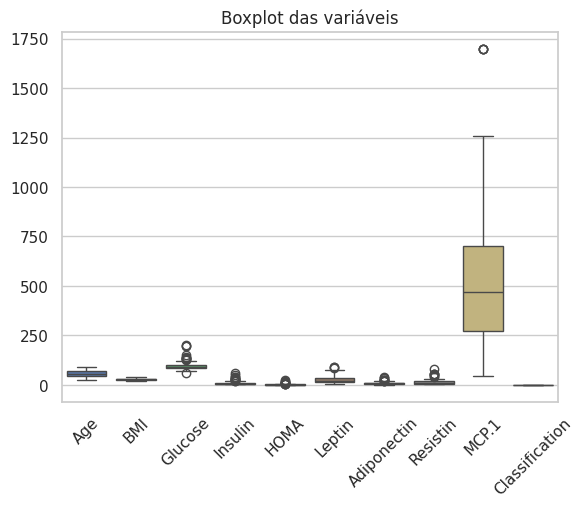

In [ ]:
plt.figure()
sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplot das variáveis")

plt.show()

**Insights**

Nesta etapa verificamos:
- valores faltantes
- outliers
- inconsistências

O dataset Coimbra é relativamente limpo e não possui muitos valores ausentes.

**Interpretação do boxplot**
- ***Variáveis com presença de outliers:*** Glucose, Insulin, HOMA, Leptin, Adiponectin, Resistin e MCP-1.
- ***Variáveis com menor presença de outliers:*** Age e BMI.
- A variável MCP-1 apresenta a maior dispersão entre todas as variáveis.

**❓ Perguntas**

- Por que limpar dados é importante?

- O que um boxplot ajuda a identificar?

- O dataset possui valores ausentes?

## 4. Análise Exploratória (EDA)

In [ ]:
# Calcula a matriz de correlação entre todas as variáveis
corr = df.corr()


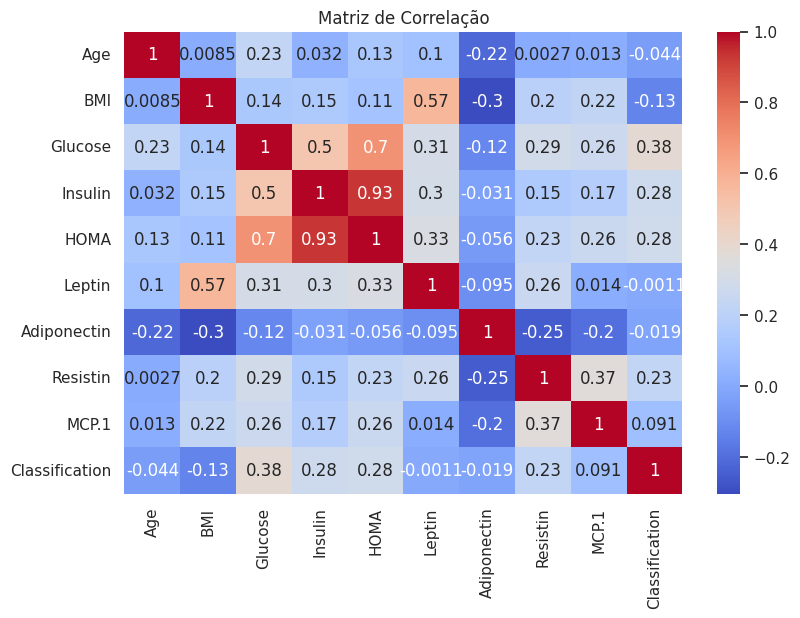

In [ ]:
plt.figure(figsize=(9,6))

# Heatmap da correlação
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

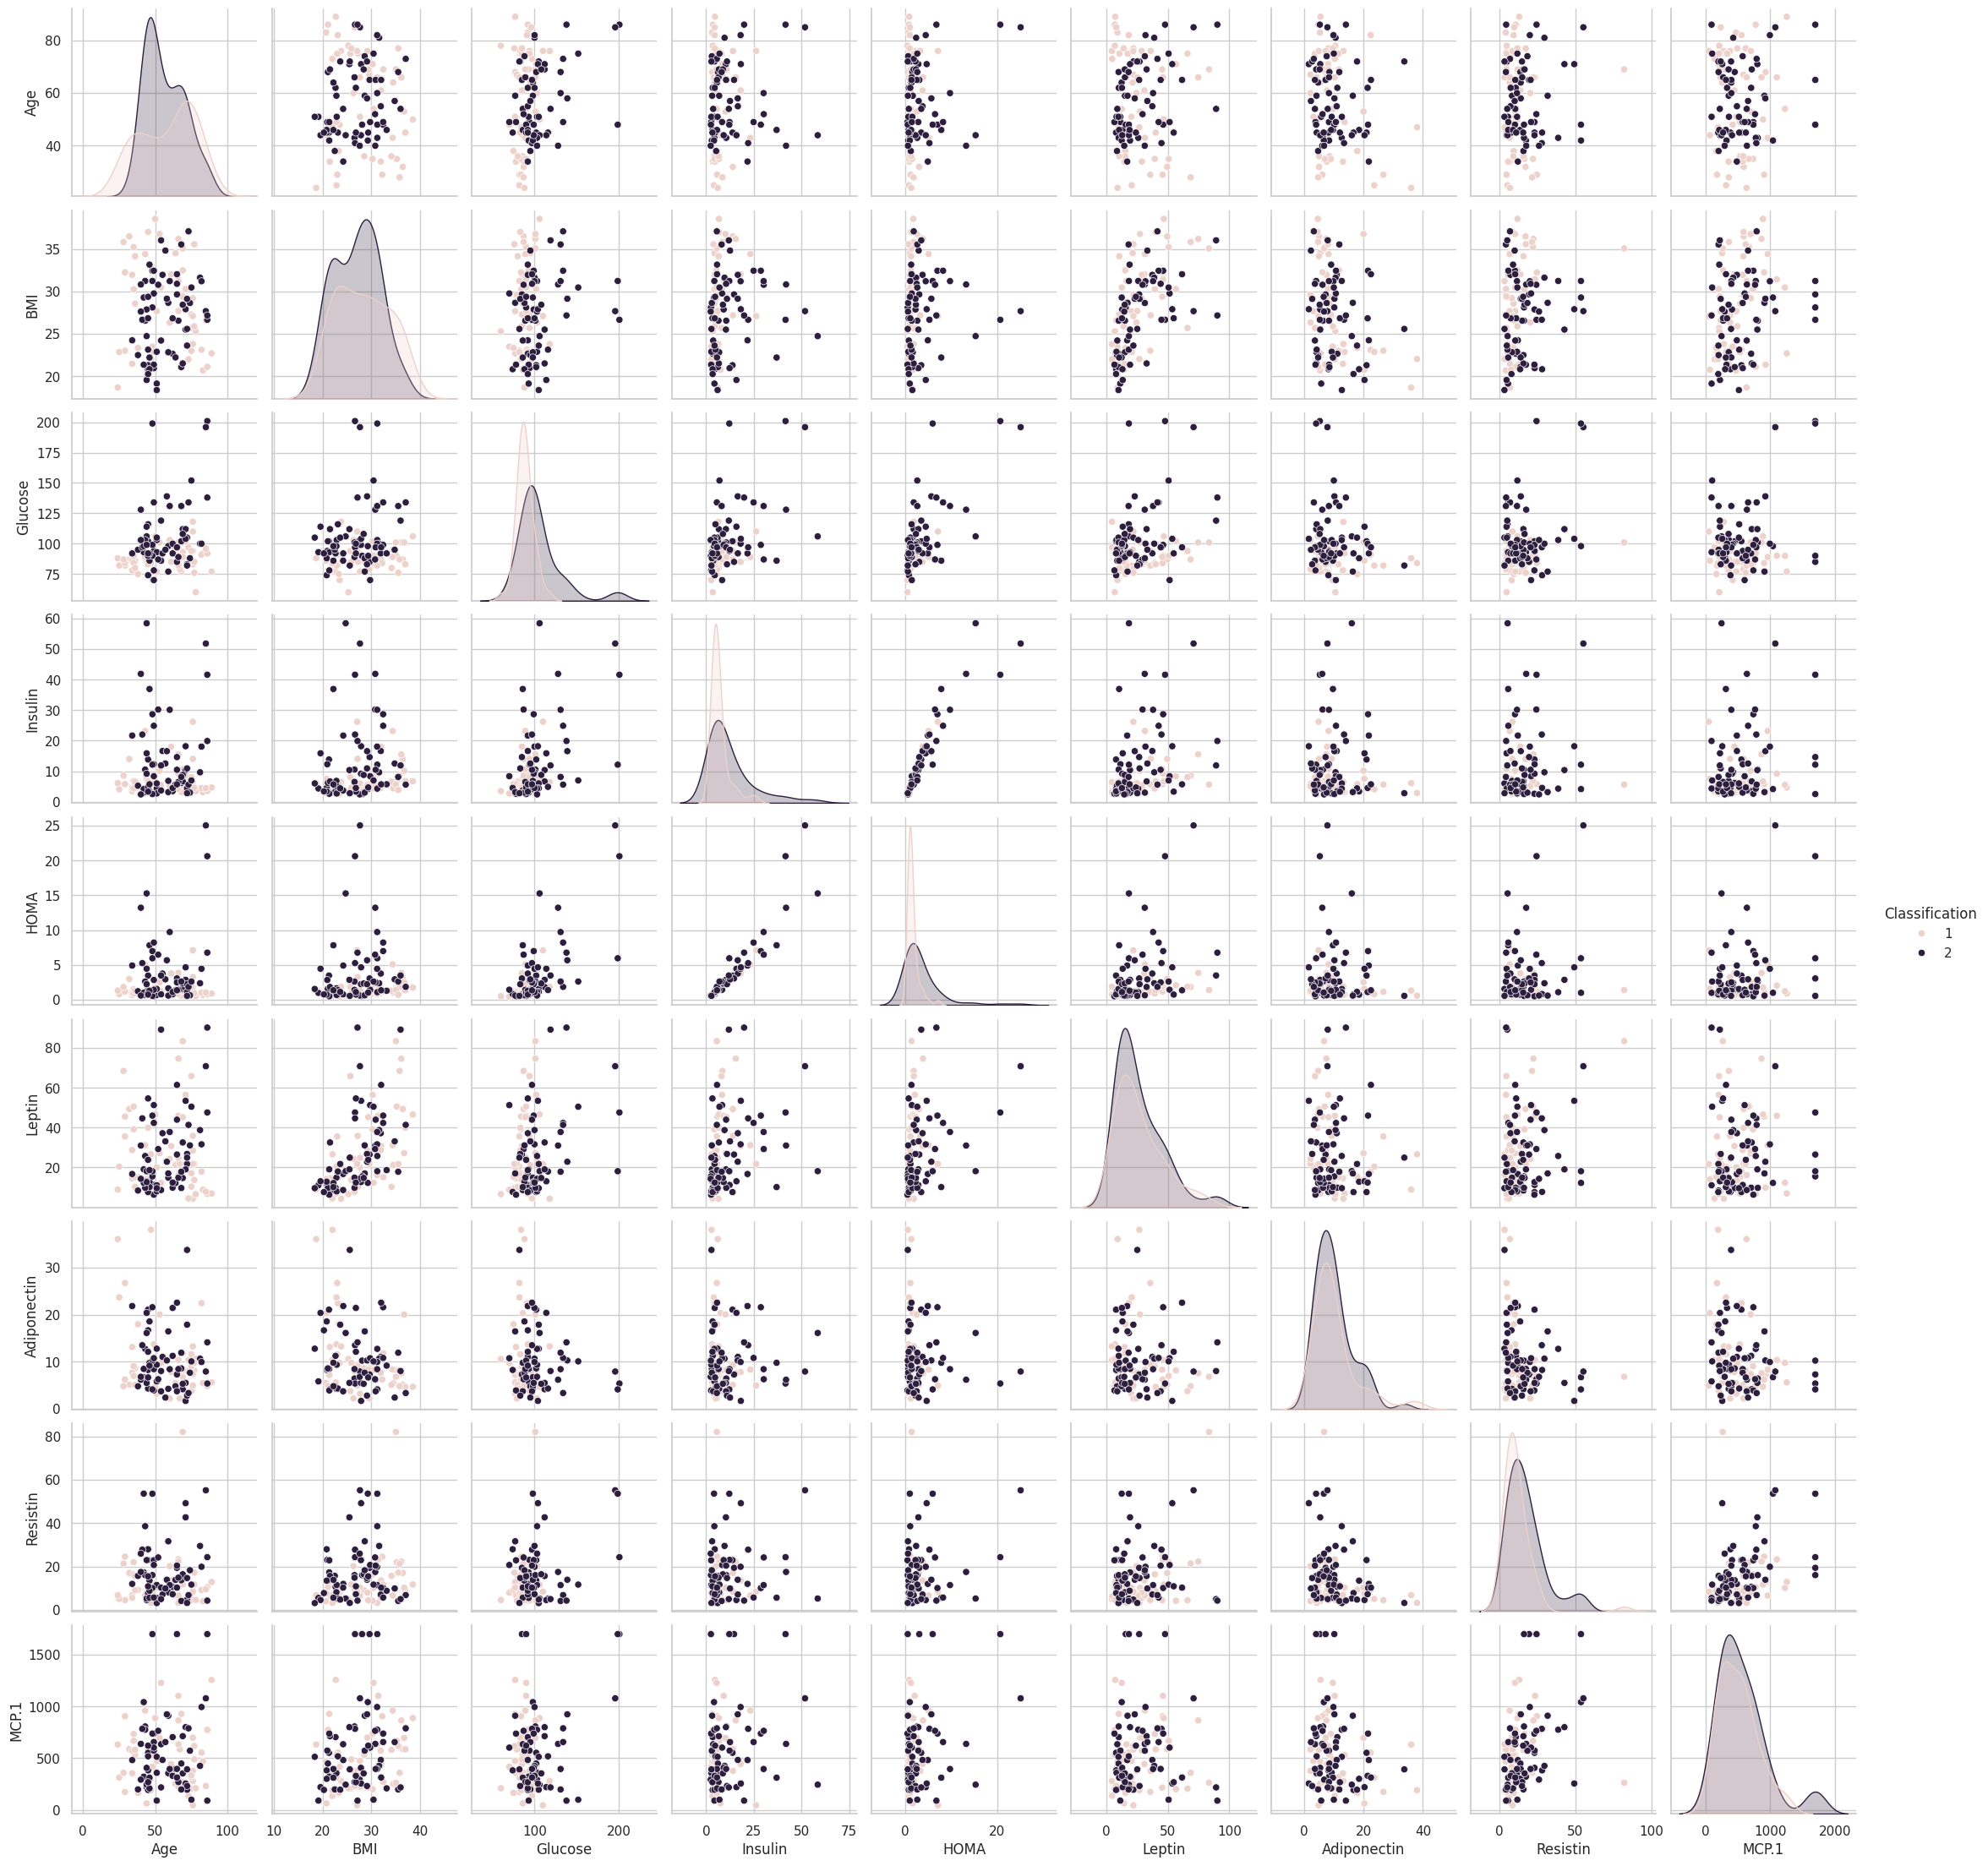

In [ ]:
# Visualização avançada
sns.pairplot(df, hue="Classification")
plt.show()


**Insights**

EDA permite:
- entender relações entre variáveis
- identificar padrões
- detectar possíveis preditores

Correlação alta com Classification pode indicar variável importante.

**❓ Perguntas**

- O que significa correlação?

- Correlação implica causalidade?

- Qual gráfico usamos para correlação?

- Qual gráfico mostra relação entre pares de variáveis?

## 5. Encontrar a Característica Mais Relevante

In [ ]:
# Calcula correlação com a variável target
cor_target = df.corr()["Classification"].abs()

# Ordena da maior para menor
relevant_features = cor_target.sort_values(ascending=False)

# Mostra as features mais relevantes
relevant_features

,Classification
Classification,1.000000
Glucose,0.384315
HOMA,0.284012
Insulin,0.276804
Resistin,0.227310
BMI,0.132586
MCP.1,0.091381
Age,0.043555
Adiponectin,0.019490
Leptin,0.001078


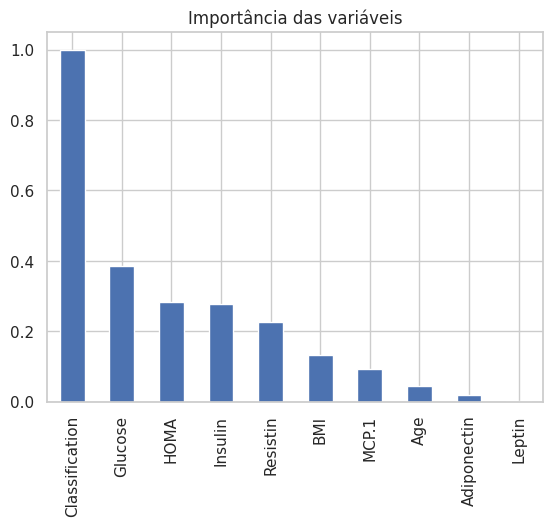

In [ ]:
plt.figure()
relevant_features.plot(kind="bar")
plt.title("Importância das variáveis")
plt.show()

**Insights**

Aqui identificamos qual variável tem maior relação com o diagnóstico.

Essas variáveis são potenciais preditores do modelo.

**❓ Perguntas**

- Por que identificar variáveis importantes?

- O que significa correlação próxima de 0?

- Qual variável parece mais relevante?

## 6. Regressão Logística

A regressão logística é usada para classificação binária.

Ela estima a probabilidade de uma classe usando a função logística.

**Função logística**

$$
P(Y=1)=\frac{1}{1+e^{-(\beta_0+\beta_1 x)}}
$$

$$
P(Y=1)=\frac{1}{1+e^{-z}}, \quad z=\beta_0+\beta_1 x
$$

**Insights**

Diferente da regressão linear:
- regressão linear → valores contínuos
- regressão logística → probabilidade entre 0 e 1

A função logística transforma valores em probabilidades entre 0 e 1.

Se a probabilidade for maior que 0.5, o modelo classifica como classe positiva.

**❓ Perguntas**

- Quando usar regressão logística?

- Qual intervalo de saída da função logística?

- O que representa essa saída?

## 7. Separar Features e Target

In [ ]:
# Remove a coluna Classification para formar as features
# X contém todas as variáveis exceto Classification
X = df.drop("Classification", axis=1)

# Define a variável target
# y contém apenas a variável alvo
y = df["Classification"]


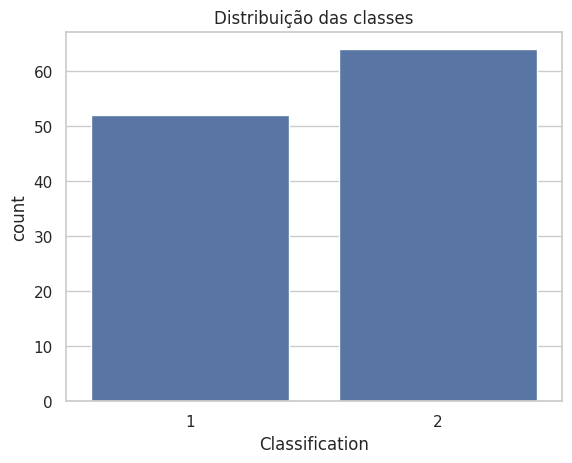

In [ ]:
plt.figure()
sns.countplot(x=y)
plt.title("Distribuição das classes")
plt.show()

**Insights**

Aqui dividimos o dataset em:
- Features (X) → variáveis preditoras
- Target (y) → variável a prever

**❓ Perguntas**

- O que são features?

- O que é target?

- Por que separar X e y?

## 8. Normalização dos Dados

In [ ]:
# Cria objeto de normalização
scaler = StandardScaler()

# Ajusta e transforma os dados
X_scaled = scaler.fit_transform(X)

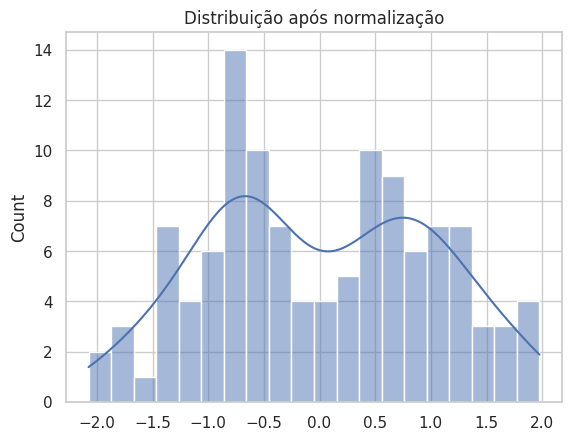

In [ ]:
plt.figure()
sns.histplot(X_scaled[:,0], bins=20, kde=True)
plt.title("Distribuição após normalização")
plt.show()

**Insights**

Normalização ajuda porque:
- coloca variáveis na mesma escala
- melhora algoritmos baseados em gradiente

**❓ Perguntas**

- O que faz a normalização?

- Qual técnica usamos?

- Por que é importante para ML?

## 9. Divisão Treino e Teste

In [ ]:
# Divide o dataset em conjunto de treino e conjunto de teste

# X_scaled -> conjunto de features normalizadas
# y -> variável alvo (classification)

# test_size = 0.2 significa que 20% dos dados serão usados para teste
# random_state garante que a divisão seja reproduzível

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Mostra o número de registros em cada conjunto
print("Tamanho do conjunto de treino:", len(X_train))
print("Tamanho do conjunto de teste:", len(X_test))

Tamanho do conjunto de treino: 92
Tamanho do conjunto de teste: 24


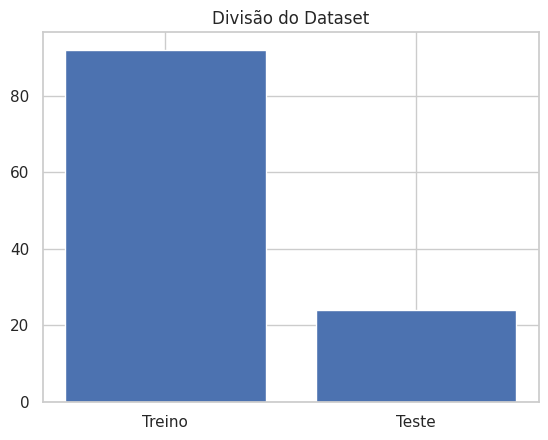

In [ ]:
# Cria um gráfico simples mostrando quantos dados foram usados em treino e teste
plt.figure()
plt.bar(["Treino","Teste"], [len(X_train), len(X_test)])
plt.title("Divisão do Dataset")
plt.show()

**Insights**

Separar treino e teste evita overfitting.
- Treino → aprende padrões
- Teste → avalia generalização

**❓ Perguntas**

- Por que não devemos treinar e testar no mesmo dataset?

- O que significa overfitting?

- Qual proporção de divisão usamos neste laboratório?

## 10. Treinar o Modelo

In [ ]:
# Cria o modelo de regressão logística
model = LogisticRegression()

In [ ]:
# Treina o modelo usando os dados de treino
# O modelo aprende a relação entre as features e a variável target
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Usa o modelo treinado para fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

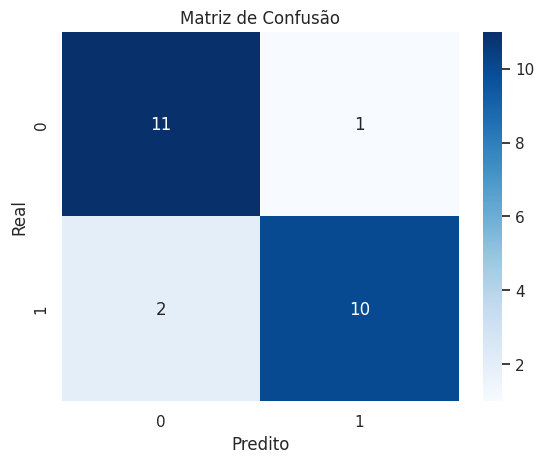

In [ ]:
# Visualização Matriz de confusão
# Calcula a matriz de confusão comparando valores reais e previstos
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Matriz de Confusão")
# Rótulos dos eixos
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**Insights**

A matriz de confusão mostra:
- verdadeiros positivos
- falsos positivos
- verdadeiros negativos
- falsos negativos

**Interpretação da matriz de confusão**
- 11 casos foram corretamente classificados como classe 0 (verdadeiros negativos).
- 10 casos foram corretamente classificados como classe 1 (verdadeiros positivos).
- 1 caso da classe 0 foi classificado incorretamente como classe 1 (falso positivo).
- 2 casos da classe 1 foram classificados incorretamente como classe 0 (falsos negativos).

Então: O modelo apresenta bom desempenho, com a maioria das classificações corretas e poucos erros de predição.

**❓ Perguntas**

- O que mede a matriz de confusão?

- O que são falsos positivos?

- Qual métrica simples podemos usar?

## 11. Accuracy do Modelo

In [ ]:
# Calcula a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy do modelo:", accuracy)

Accuracy do modelo: 0.875


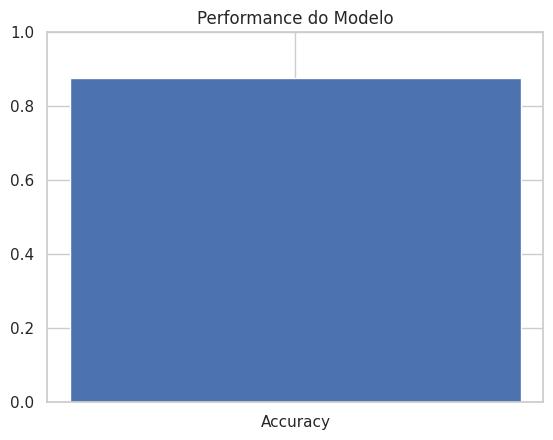

In [ ]:
# Cria gráfico simples mostrando a acurácia
plt.figure()

# Cria barra com valor da acurácia
plt.bar(["Accuracy"], [accuracy])

# Limita eixo entre 0 e 1
plt.ylim(0,1)

plt.title("Performance do Modelo")
plt.show()

**Insights**

A accuracy mede a proporção de previsões corretas:
$$
Accuracy=\frac{PrevisõesCorretas}{TotalPrevisões}
$$

Se o modelo tiver accuracy = 0.85, significa que 85% das previsões estão corretas.

Porém, em datasets desbalanceados a accuracy pode ser enganosa.

**❓ Perguntas de reflexão**

- O que significa accuracy = 0.9?

- Accuracy sempre é suficiente para avaliar um modelo?

- Qual outra ferramenta usamos para avaliar classificadores?

## 12. Curva ROC

In [ ]:
# Calcula as probabilidades previstas pelo modelo para cada observação do conjunto de teste
# predict_proba retorna a probabilidade de cada classe; [:,1] seleciona a probabilidade da classe positiva (câncer)
y_prob = model.predict_proba(X_test)[:,1]

# Calcula os pontos necessários para construir a curva ROC
# y_test -> valores reais das classes
# y_prob -> probabilidades previstas pelo modelo
# pos_label=2 indica que a classe positiva é "2" (pacientes com câncer)
# fpr -> False Positive Rate (taxa de falsos positivos)
# tpr -> True Positive Rate (taxa de verdadeiros positivos ou sensibilidade)
# thresholds -> diferentes limiares de decisão usados para gerar a curva
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=2)

# Calcula a AUC (Area Under the Curve), que representa a área sob a curva ROC
# Quanto mais próximo de 1, melhor a capacidade do modelo de distinguir entre as classes
auc = roc_auc_score(y_test, y_prob)

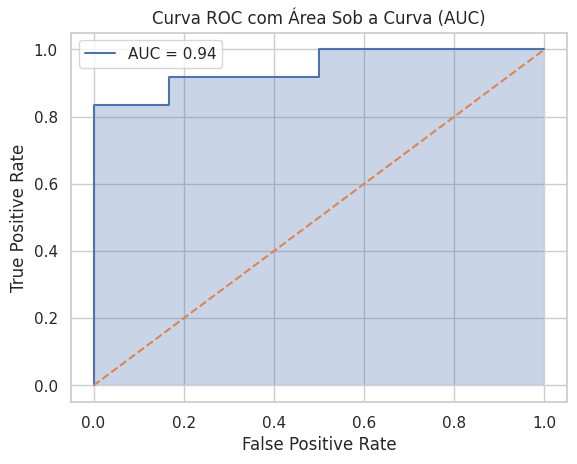

In [ ]:
# Cria figura
plt.figure()

# Plota a curva ROC do modelo
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

# Preenche a área sob a curva ROC
plt.fill_between(fpr, tpr, alpha=0.3)

# Plota linha diagonal de referência (classificador aleatório)
plt.plot([0,1], [0,1], linestyle="--")

# Rótulos dos eixos
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC com Área Sob a Curva (AUC)")

# Mostra legenda
plt.legend()
plt.show()

**Insights**

A curva ROC mostra o equilíbrio entre:
- True Positive Rate (sensibilidade)
- False Positive Rate

A linha diagonal representa um classificador aleatório.

Quanto mais a curva estiver próxima do canto superior esquerdo, melhor o modelo.

A AUC mede a qualidade do classificador:
| AUC     | Qualidade |
| ------- | --------- |
| 0.5     | aleatório |
| 0.7–0.8 | razoável  |
| 0.8–0.9 | bom       |

**❓ Perguntas de reflexão**

- O que representa a linha diagonal na curva ROC?

- O que significa AUC = 0.5?

- O que indica uma curva próxima do canto superior esquerdo?

## 13. Conclusão Final
- *EDA ajuda a entender o dataset:*
A análise exploratória permitiu visualizar a distribuição das variáveis, identificar possíveis outliers e observar relações entre características biomédicas.

- *Seleção de características ajuda a identificar variáveis relevantes:*
A análise de correlação mostrou quais variáveis apresentam maior relação com a variável alvo (Classification).

- *Normalização melhora modelos de Machine Learning:*
Padronizar as variáveis ajuda algoritmos como regressão logística a aprender de forma mais estável.

- *Regressão logística permite resolver problemas de classificação:*
O modelo foi capaz de estimar a probabilidade de um paciente pertencer à classe positiva (câncer).

- *Métricas de avaliação são essenciais:*
Accuracy, matriz de confusão e curva ROC ajudam a avaliar o desempenho do modelo.

- *AUC resume o poder discriminatório do modelo:*
Quanto maior a área sob a curva ROC, melhor a capacidade do modelo de distinguir entre pacientes saudáveis e pacientes com câncer.